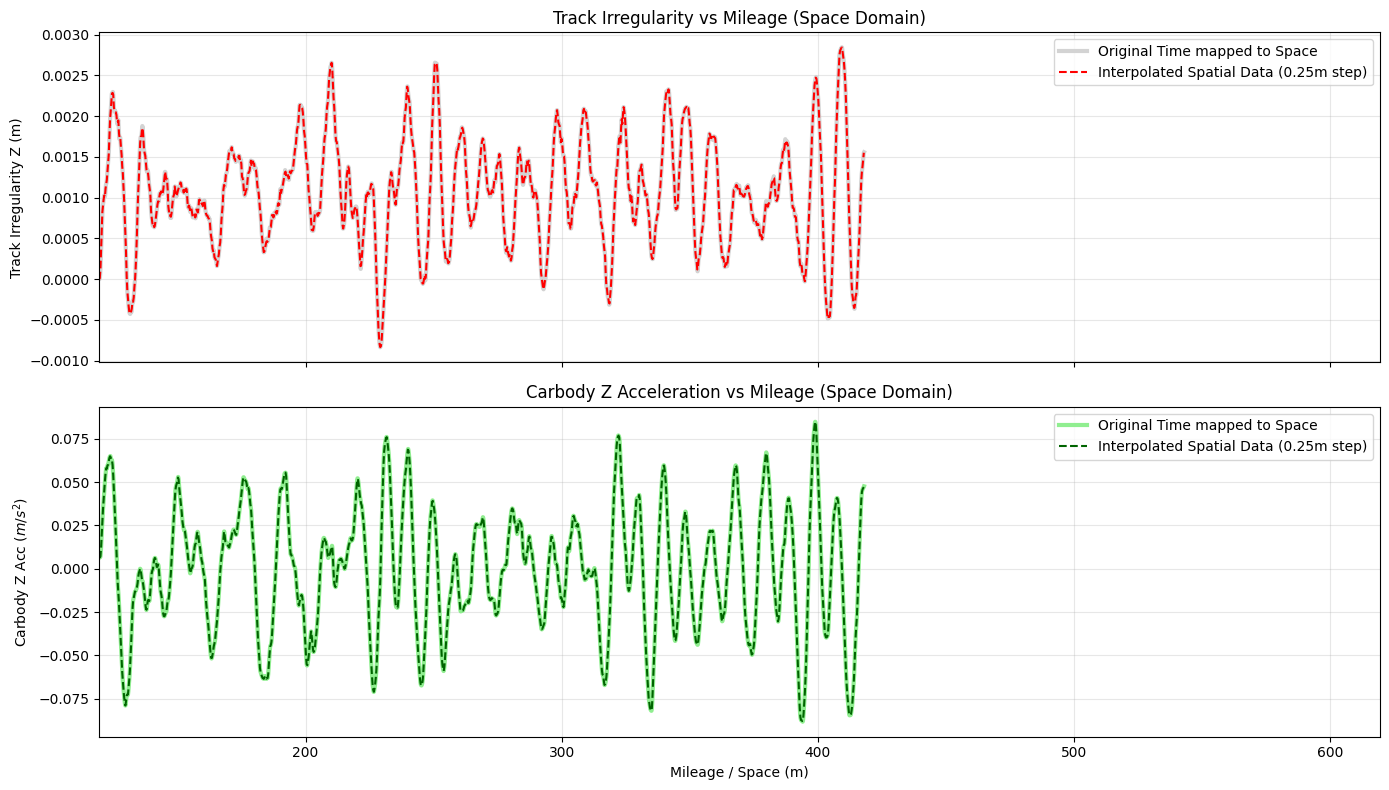

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# 定义数据路径
base_dir = Path("/media/jdtm/wgx/VTCM_PYTHON/results/default_project/高速客车-外部导入-vehicle-standard-20260322_065703/files")
time_npz = base_dir / "simulation_result.npz"
space_npz = base_dir / "simulation_result_spatial.npz"

# 加载原始时域数据
data_t = np.load(time_npz)
# 加载插值转换后的空域（里程）数据
data_s = np.load(space_npz)

# 基础参数
v_kmh = 215.0
v_ms = v_kmh / 3.6
t_step = 1e-4

# 提取时域数据
# Some arrays (like Irre_bz_L_ref) might be 1 step longer than X, so we use min logic to align them properly
min_len = min(len(data_t['X']), len(data_t['Irre_bz_L_ref']))
t_array = np.arange(min_len) * t_step
s_array_mapped = t_array * v_ms  # 根据速度物理映射到空间

# 我们在这里提取两个信号作为对比：
# 1. 外部不平顺激励 (左侧垂向 Irre_bz_left_ref)
# 2. 车体垂向加速度 (索引说明: 车体[0-4], Z是索引1, 对应 A[:, 1])
irre_t = data_t['Irre_bz_L_ref'][:min_len]
acc_z_t = data_t['A'][:min_len, 1]

# 提取空域插值数据
s_array_interp = data_s['spatial_s']
irre_s = data_s['Irre_bz_L_ref']
acc_z_s = data_s['A'][:, 1]

# ==================== 绘图 ====================
fig, axes = plt.subplots(2, 1, figsize=(14, 8), dpi=100, sharex=True)

# 图 1: 轨道不平顺对比
axes[0].plot(s_array_mapped, irre_t, label="Original Time mapped to Space", color='lightgray', linewidth=3)
axes[0].plot(s_array_interp, irre_s, label="Interpolated Spatial Data (0.25m step)", color='red', linestyle='--', linewidth=1.5)
axes[0].set_ylabel("Track Irregularity Z (m)")
axes[0].set_title("Track Irregularity vs Mileage (Space Domain)")
axes[0].legend()
axes[0].grid(True, alpha=0.3) 

# 图 2: 车体垂向加速度对比
axes[1].plot(s_array_mapped, acc_z_t, label="Original Time mapped to Space", color='lightgreen', linewidth=3)
axes[1].plot(s_array_interp, acc_z_s, label="Interpolated Spatial Data (0.25m step)", color='darkgreen', linestyle='--', linewidth=1.5)
axes[1].set_ylabel("Carbody Z Acc ($m/s^2$)")
axes[1].set_title("Carbody Z Acceleration vs Mileage (Space Domain)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 设置 x 轴显示范围，重点看转换后的那一段（跳过了前 2s）
axes[1].set_xlabel("Mileage / Space (m)")
start_s = s_array_interp[0]
end_s = s_array_interp[-1]
# 我们可以缩小一下视野，看中间的500米细节
axes[1].set_xlim(start_s, start_s + 500) 

plt.tight_layout()
plt.show()